California Housing model (Linear Regression and Random Forest regression via sklearn)

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

Importing the data. Source: https://www.kaggle.com/datasets/nalisha/california-housing-prices-dataset-clean-and-ml/data

In [4]:
data = pd.read_csv("housing.csv")
display(data.head())

print("-----Data Shape----\n")
print(data.shape)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


-----Data Shape----

(20640, 10)


Get some key features of the data.

In [6]:
print("\n-----Description-----\n")
display(data.describe())

print("\n----Information-----\n")
display(data.info())

print("\n-----Columns Name------\n")
data_1 = pd.DataFrame(data.columns, columns = ["Columns Name"])
display(data_1)



-----Description-----



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



----Information-----

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None


-----Columns Name------



,Columns Name
0,longitude
1,latitude
2,housing_median_age
3,total_rooms
4,total_bedrooms
5,population
6,households
7,median_income
8,median_house_value
9,ocean_proximity


Notice, for now, that there are miss data in the total_bedrooms column. We must address this.

For now, as we want to predict the median_house_value, let us first check if it has a good distribution for a better model.

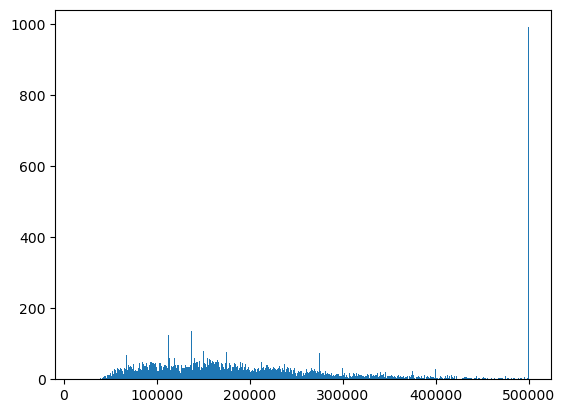

In [8]:
y0 = data["median_house_value"]
plt.hist(y0.to_numpy(), bins=1000)
plt.savefig("images/median_house_value_distribution.png", dpi=150, bbox_inches='tight') 
plt.show()

Now, we see some odd data around 500000. This doesn't look coherent to the overall data. I found that, by filtering them out, I get much better model. Let us filter these odd data out.

In [10]:
data_filter = data[data["median_house_value"] < 495000]
data_filter.shape

(19629, 10)

Now, we see some odd data around 500000. This doesn't look coherent to the overall data. I found that, by filtering them out, I get much better model. Let us filter these odd data out.

In [12]:
print("\n-----Before Missing Value------\n")
display(data_filter.isnull().sum())

data_filter["total_bedrooms"].fillna(data_filter["total_bedrooms"].median(), inplace=True)
print("\n-----After Missing Value------\n")
display(data_filter.isnull().sum())


-----Before Missing Value------



longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


-----After Missing Value------



/var/folders/yh/z6n8z11940qcsd35tldkmvvst3wtn3/T/ipykernel_16860/2158555487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filter["total_bedrooms"].fillna(data_filter["total_bedrooms"].median(), inplace=True)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Check again if the data makes sense now.

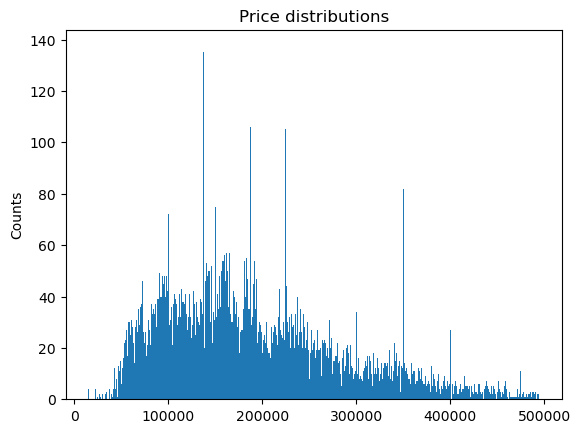

In [14]:
y = data_filter["median_house_value"]
X0 = data_filter.drop(["median_house_value"], axis =1)

plt.hist(y.to_numpy(), bins=1000)
plt.title("Price distributions")
plt.ylabel("Counts")
plt.savefig("images/median_house_value_distribution_filtered.png", dpi=150, bbox_inches='tight') 
plt.show()

Now, we want to index the data for the ocean proximity category. But first, we want to check how many unique values are there for ocean category column.

In [16]:
print("\n------unique Value-------\n")
display(X0.filter(like = "ocean_proximity").nunique())


------unique Value-------



ocean_proximity    5
dtype: int64

As there are 5 categories in this, we can index them sufficiently as follows.

In [18]:
X = pd.get_dummies(X0, columns = ["ocean_proximity"], drop_first = True)
display(X.filter(like = "ocean_proximity"))

,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0
...,...,...,...,...
20635,1,0,0,0
20636,1,0,0,0
20637,1,0,0,0
20638,1,0,0,0


Note, that the last missing one is "less than 1H from ocean". This corresponds to when the all 4 categories above are 0. Here are some plots vs the price and the histograms for the distribution of the data for each categories.

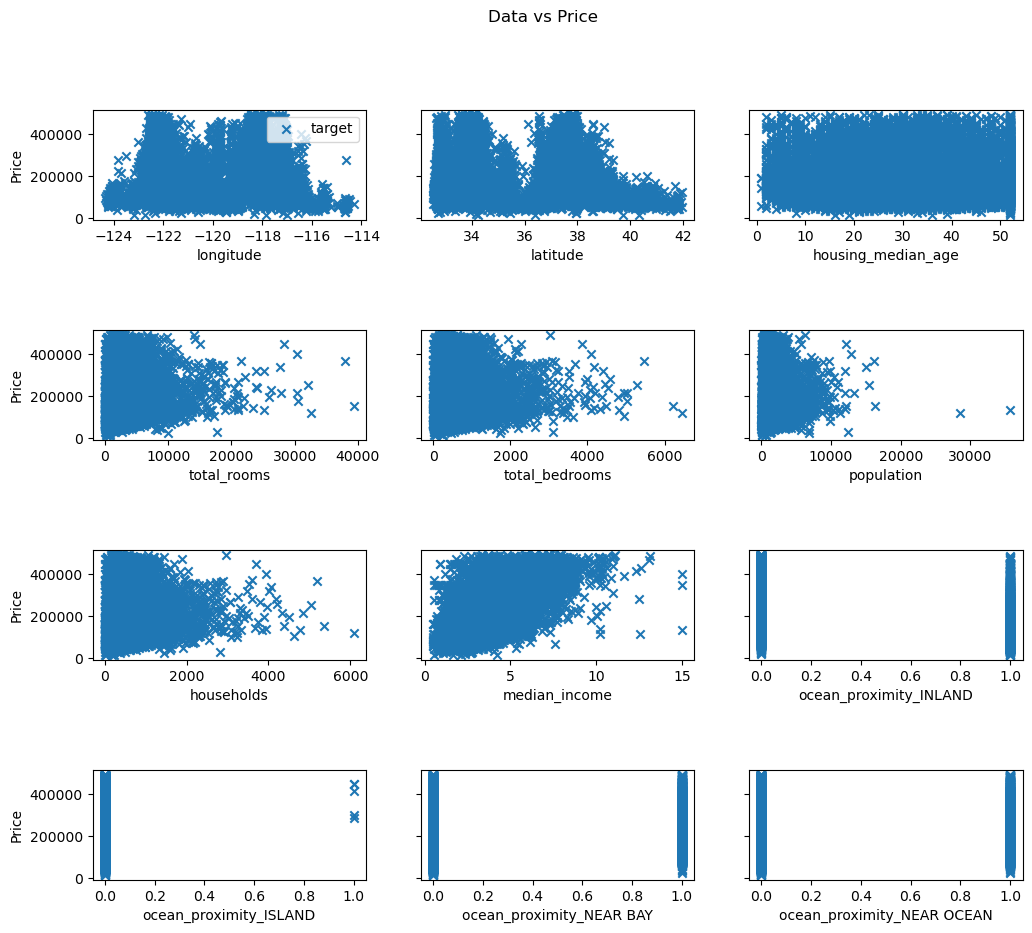

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


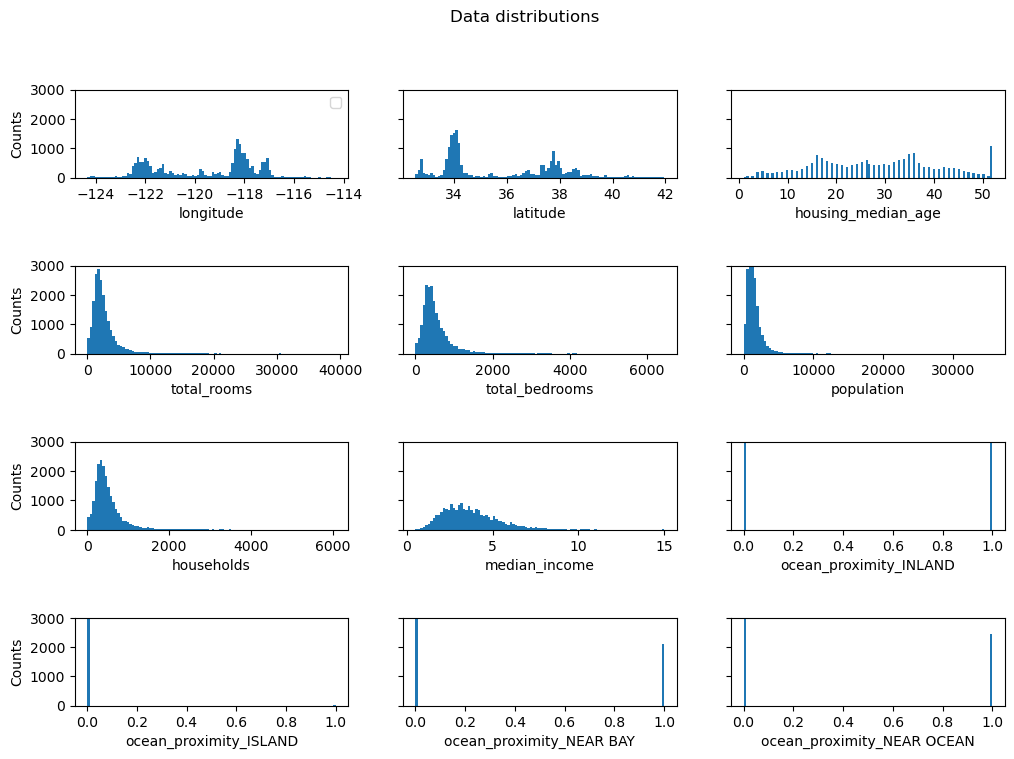

In [20]:
fig, ax = plt.subplots(4, 3, figsize=(12, 10), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X.iloc[:, i].to_numpy(), y.to_numpy(), label='target', marker = 'x')
    ax[row, col].set_xlabel(X.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Data vs Price")
plt.savefig("images/data_vs_price.png", dpi=150, bbox_inches='tight') 
plt.show()

fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
plt.ylim(0,3000)
for j, i in enumerate(range(0, 12)):
    row = j//3
    col = j%3
    # Plot histogram
    ax[row, col].hist(X.iloc[:, i].to_numpy(), bins=100)
    ax[row, col].set_xlabel(X.columns[i])
    ax[row,0].set_ylabel("Counts")

ax[0,0].legend()
fig.suptitle("Data distributions")
plt.savefig("images/data_distribution.png", dpi=150, bbox_inches='tight') 
plt.show()

To buit the learning model, we now want to:

First, we want to split the data into training set and testing set (70:30 in for my model). This way, we can produce the model via the training set and test it with the testing set.

Second, for faster convergence, we want to rescale the data. I this model, I choose the StandarScaler (respect to its mean and standard deviation).

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)  
X_test_norm = scaler.transform(X_test) 

Now, we can fit the model.

In [24]:
sgdr = SGDRegressor(max_iter=2000)
sgdr.fit(X_train_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")
print(f"Converged: {sgdr.n_iter_ < sgdr.max_iter}")

SGDRegressor(max_iter=2000)
number of iterations completed: 20, number of weight updates: 274801.0
Converged: True


We can check the parameters here.

In [26]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")

model parameters:                   w: [-46738.54299327 -46832.30773767  11435.62184686 -14728.63450703
  29403.11673808 -32562.07337558  19233.55202616  59345.23000071
 -18724.48545299    509.58072107  -2362.81090688   2307.16195775], b:[191393.89519386]


Note that two are two ways you can make the prediction. Both ways should agree.

In [28]:
# make a prediction using sgdr.predict()
y_pred_sgd = sgdr.predict(X_test_norm)
# make a prediction using w,b. 
y_pred = np.dot(X_test_norm, w_norm) + b_norm  
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

prediction using np.dot() and sgdr.predict match: True


Now, let us test the prediction of trained model and the testing data.

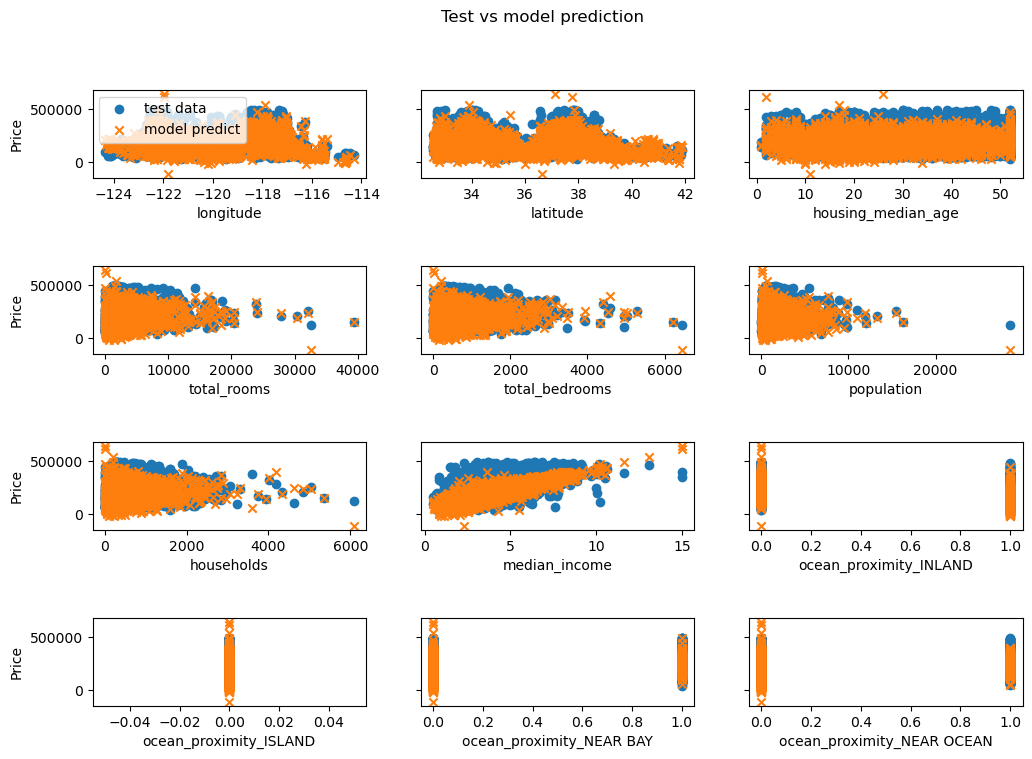

In [30]:
fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X_test.iloc[:, i].to_numpy(), y_test.to_numpy(), label='test data')
    # plot prediction
    ax[row, col].scatter(X_test.iloc[:, i], y_pred, label='model predict', marker = 'x')
    ax[row, col].set_xlabel(X_train.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Test vs model prediction")
plt.savefig("images/Test_vs_model.png", dpi=150, bbox_inches='tight') 
plt.show()

That looks good. We can also quanlitatively check to see how well the model matches the data using the R2 score, given by:

In [32]:
r2_score(y_test, y_pred_sgd)

0.6160920082394641

The linear regression model only gives 61.6% of the R2 score. Unsuprisingly, this is because the nature of the data itself is non-linear. To further impove the prediction, let us try other model.

In this project, I would to try the Random forest model. The reason for this is that it can handle the non-linear nature of the data very weel. By randomly grouping data into numbers of trees, each tree will make a prediction of the price. The final prediction result is given by the average of all trees. 

Here, we start with 200 trees. 

In [69]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=40)
rf.fit(X_train_norm, y_train)
y_pred_rf = rf.predict(X_test_norm)
print(r2_score(y_test, y_pred_rf)) 

0.7900995895205284


Clearly, the R2 score is much improved compared to the linear regression model. However, it can be further optimised for better predictions. Before doing so, let us understand what happens inside each tree.

For each tree, the data is split at decision nodes, where the splitting feature is randomly chosen from a subset of sqrt(N) features. In our case, there are 12 features in total, such as latitude and longitude. Each decision node asks a simple yes or no question based on a threshold, for example "is median_income > 3.5?". This splitting process continues until it reaches the maximum depth, or until a node has too few samples to split further, which is controlled by the minimum samples split parameter. Once a branch can no longer split, it becomes a leaf, and the prediction at that leaf is simply the average price of all training rows that ended up there.

The final prediction for any new data point is the average of the leaf predictions across all trees.
We can therefore optimise this model with respect to the number of trees, maximum depth, and minimum samples split. This can be done using GridSearchCV, which tries every possible combination of parameters. However, since this can be quite slow for a large parameter grid, I used RandomizedSearchCV instead, which samples a fixed number of random combinations and finds a good configuration much faster.

In [164]:
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [1, 2, 5, 10]
}

rf_base = RandomForestRegressor(random_state=40)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=24,          # only tries 20 random combinations instead of all 48
    cv=5, # 5-fold cross validation
    scoring="r2", # optimise for R2
    n_jobs=-1, # use all CPU cores to speed it up
    random_state=40 
)

random_search.fit(X_train_norm, y_train)

print("Best parameters:", random_search.best_params_)
print("Best R2 score:", random_search.best_score_)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Extracting the best configuration.

In [166]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_norm)
print("Test R2:", r2_score(y_test, y_pred_tuned))

Test R2: 0.7909081802332119


The best model is only slightly better R2 score than the "naive" model. Here, let see parameters inside a tree, 112th.

In [174]:
tree = best_rf.estimators_[112]

print(f"Max depth reached:     {tree.get_depth()}")
print(f"Number of leaves:      {tree.get_n_leaves()}")
print(f"Number of nodes:       {tree.tree_.node_count}")
print(f"Feature at each node:  {tree.tree_.feature}")
print(f"Threshold at each node:{tree.tree_.threshold}")

Max depth reached:     30
Number of leaves:      8543
Number of nodes:       17085
Feature at each node:  [ 7  8  7 ...  1 -2 -2]
Threshold at each node:[ 0.25346529  0.35668445 -0.6240994  ...  0.14828834 -2.
 -2.        ]


Now, let's look into the Random Forest model and how each feature contributes to the model via Feature importance. The feature importance tells you that which feature gives the error reduction the most (mean square error in this model). That is, it tells you what data you should be looking at to make a well prediction.

                       Feature  Importance
7                median_income    0.436334
8       ocean_proximity_INLAND    0.161114
0                    longitude    0.118194
1                     latitude    0.110654
2           housing_median_age    0.048045
5                   population    0.036683
3                  total_rooms    0.029005
4               total_bedrooms    0.025589
6                   households    0.021999
11  ocean_proximity_NEAR OCEAN    0.010667
10    ocean_proximity_NEAR BAY    0.000997
9       ocean_proximity_ISLAND    0.000720


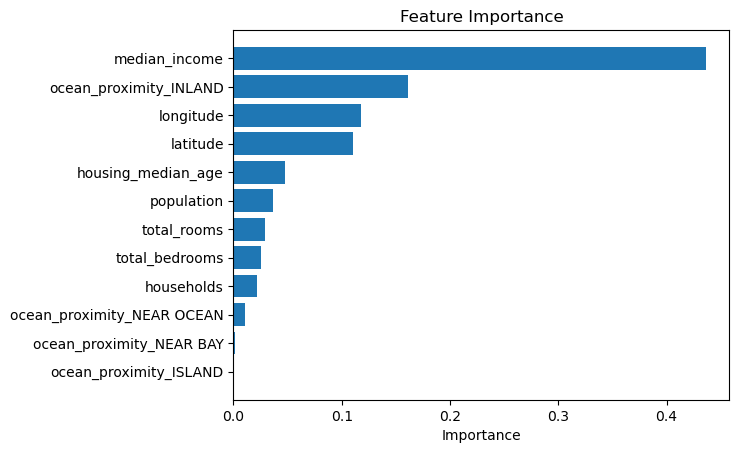

In [170]:
importances = best_rf.feature_importances_
feature_names = X_train.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.savefig("images/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

That is the median income highly contributes to the accurate model. Note that there may be biases towards unique features like ocean proximity as these are registered only 0 and 1.

Let's visualise the random forest model with the test data.

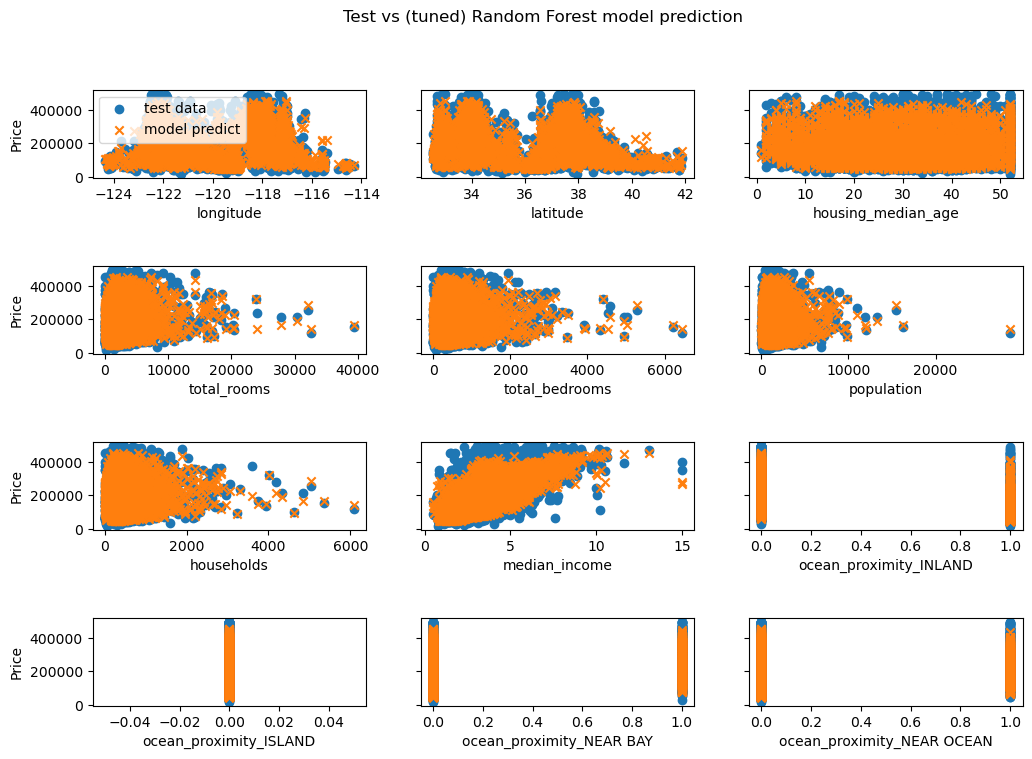

In [172]:
fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X_test.iloc[:, i].to_numpy(), y_test.to_numpy(), label='test data')
    # plot prediction
    ax[row, col].scatter(X_test.iloc[:, i], y_pred_tuned, label='model predict', marker = 'x')
    ax[row, col].set_xlabel(X_train.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Test vs (tuned) Random Forest model prediction")
plt.savefig("images/Test_vs_model_rf.png", dpi=150, bbox_inches='tight') 
plt.show()

Conclusion

In this project, I built and compared two models, Linear Regression and Random Forest, to predict median house prices in California. I began by cleaning the data, which involved filtering out extreme values near the $500,000 cap and filling missing values in the total_bedrooms column with the column median.

Linear Regression achieved an R2 score of 61.5%, which serves as a reasonable baseline. Switching to Random Forest improved this to 79.1%. The improvement is expected, as the relationship between the features and house price is non-linear in nature, which linear regression cannot capture but Random Forest handles well through its ensemble of decision trees.

Looking inside the model via feature importance, median income turned out to be the strongest predictor by a significant margin, accounting for 43.6% of the model's decisions. Location features such as latitude and longitude were the next most influential, which makes intuitive sense given how strongly neighbourhood affects property value.

To push the R2 score further, one could explore additional feature engineering, try a more exhaustive hyperparameter search, or experiment with gradient boosting models such as XGBoost, which often outperform Random Forest on structured tabular data. The tradeoff, however, is greater computational complexity and longer training time.